# SPACER Predict Notebook

## Example Data Setup
Run the cell below to use the synthetic example dataset.
Swap the three path variables for your own files when running on real data.

| Variable | Example value | Description |
|---|---|---|
| `GENE_CSV` | `data/example_genes.csv` | 377-gene reference list |
| `ADATA_H5AD` | `data/example_spatial.h5ad` | 600-cell AnnData (400 tumour + 200 stromal) |
| `MODEL_PATH` | `sample_output/best_model.pth` | Model saved by `train_show.ipynb` |

**Synthetic label layout:** Macrophage+ cells occupy the right half of the tissue (X > 190).

In [10]:
# ── Example data paths (swap for your own files) ──────────────────────────────
# Run `python create_example_data.py` once to generate the files below.
import os

GENE_CSV    = 'data/example_genes.csv'      # reference gene list
ADATA_H5AD  = 'data/example_spatial.h5ad'  # synthetic AnnData
MODEL_PATH  = 'sample_output/best_model.pth'  # from train_show.ipynb
IMMUNE_CELL = 'macrophage'

# If train_show.ipynb has not been run yet, save an untrained placeholder
if not os.path.exists(MODEL_PATH):
    import torch, pandas as pd
    from model.model import MIL as _MIL
    _genes = pd.read_csv(GENE_CSV)['Gene'].tolist()
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    torch.save(_MIL(_genes).state_dict(), MODEL_PATH)
    print(f"Saved untrained placeholder → {MODEL_PATH}")
    print("Run train_show.ipynb first for a properly trained model.")
else:
    print(f"Model found: {MODEL_PATH}")

Model found: sample_output/best_model.pth


In [11]:
import csv
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import scanpy as sc
from torch.utils.data import DataLoader
from model.model import MIL

In [12]:
from torch.utils.data import Dataset
import scipy.sparse as sp
from scipy.spatial.distance import cdist
from tqdm import trange
from scipy.sparse import issparse


def map_immune_cell(tag: str) -> str:
    mapping = {
        "tcell":       "T",
        "bcell":       "B",
        "macrophage":  "Macrophage",
        "neutrophil":  "Neutrophil",
        "fibroblast":  "Fibroblast",
        "endothelial": "Endothelial",
    }
    if tag in mapping:
        return mapping[tag]
    raise ValueError(f"Invalid immune cell type: {tag}")


def preprocess_data(adata, immune_cell, n_genes=500, resolution="low"):
    has_label = immune_cell is not None
    if has_label and immune_cell not in adata.obs.columns:
        immune_cell = map_immune_cell(immune_cell)

    adata = adata.copy()
    adata.var_names_make_unique()

    tumour = adata[adata.obs["cell_type"].astype(int) == 1].copy()

    if issparse(tumour.X):
        mean_expr = np.asarray(tumour.X.mean(axis=0)).ravel()
    else:
        mean_expr = tumour.X.mean(axis=0)

    gene_names = tumour.var_names
    n_genes = min(n_genes, int(0.2 * len(gene_names))) if n_genes > len(gene_names) else n_genes
    top_idx  = mean_expr.argsort()[-n_genes:][::-1]
    top_genes = gene_names[top_idx]

    tumour_gene_set = [
        "PRAME", "MUC1", "EPCAM", "PMEL", "MAGEA3", "WT1",
        "MYC", "CCND1", "CDK4", "CDK6", "BCL2", "BIRC5",
    ]
    hla_genes = [g for g in adata.var_names if g.startswith("HLA")]

    keep = list(dict.fromkeys(tumour_gene_set + hla_genes + list(top_genes)))
    drop = {"CD68", "STAT1", "MMP13"}
    keep = [g for g in keep if g in adata.var_names and g not in drop]

    adata = adata[:, keep].copy()

    if has_label:
        adata.obs[immune_cell] = adata.obs[immune_cell].astype(float)
        if resolution != "high":
            if not set(adata.obs[immune_cell].unique()).issubset({0, 1}):
                thresh = np.percentile(
                    adata[adata.obs["cell_type"] == 1].obs[immune_cell], 75
                )
                adata.obs[immune_cell] = (adata.obs[immune_cell] > thresh).astype(int)
    else:
        adata.obs["dummy_label"] = -1
        immune_cell = "dummy_label"

    return adata


class BagsDataset(Dataset):
    # mode='train': returns [pos + k-1 neg] bags; mode='infer': returns one bag (label=-1)
    def __init__(self, input_data, immune_cell="tcell", max_instances=None,
                 radius=200, resolution="low", n_genes=500, k=2, mode="train"):
        self.mode = mode.lower()
        self.k    = k
        self.radius = radius
        self.resolution = resolution
        self.max_instances = max_instances
        self.n_genes = n_genes
        self.immune_cell = (
            map_immune_cell(immune_cell) if (immune_cell and self.mode == "train") else None
        )

        if isinstance(input_data, str):
            df = pd.read_csv(input_data)
            adata_list = []
            for _, row in df.iterrows():
                ad  = sc.read_h5ad(row["adata"])
                r   = row.get("radius",     self.radius)
                res = row.get("resolution", self.resolution)
                ad_prep = preprocess_data(ad, self.immune_cell, n_genes, res)
                adata_list.append((ad_prep, r, res))
            self.batches = self._build_bags(adata_list)
        elif hasattr(input_data, "X"):
            ad = preprocess_data(input_data, self.immune_cell, n_genes, resolution)
            self.batches = self._build_bags([(ad, radius, resolution)])
        else:
            raise ValueError("input_data must be an AnnData or a CSV path")

    def __len__(self):  return len(self.batches)
    def __getitem__(self, idx): return self.batches[idx]

    def _build_bags(self, adata_radius_list):
        train_batches, infer_items = [], []
        for adata, radius, resolution in adata_radius_list:
            coords     = adata.obs[["X", "Y"]].astype(float).to_numpy()
            expr       = adata.X
            barcodes   = adata.obs_names.to_numpy()
            gene_names = adata.var_names.tolist()
            if self.mode == "train":
                labels = adata.obs[self.immune_cell].astype(int).to_numpy()
            else:
                labels = np.full(adata.n_obs, -1, dtype=int)
            cell_types = adata.obs["cell_type"].astype(int).to_numpy()
            pos_bags, neg_bags = [], []

            for i in trange(adata.n_obs, desc=f"[{self.mode}] r={radius}", leave=False):
                if cell_types[i] == 0:
                    continue
                dist  = cdist([coords[i]], coords)[0]
                neigh = np.where(dist <= radius)[0]
                neigh = neigh[cell_types[neigh] == 1]
                if resolution == "high":
                    neigh = neigh[neigh != i]
                if len(neigh) == 0:
                    continue
                if self.max_instances and len(neigh) > self.max_instances:
                    continue
                bag = {
                    "distances":       dist[neigh, None].astype(np.float32),
                    "gene_expression": expr[neigh],
                    "label":           labels[i],
                    "core_idx":        i,
                    "gene_names":      gene_names,
                    "cell_id":         barcodes[i],
                }
                if self.mode == "train":
                    (pos_bags if labels[i] == 1 else neg_bags).append(bag)
                else:
                    infer_items.append(bag)

            if self.mode == "train":
                k_neg   = self.k - 1
                n_batch = min(len(pos_bags), len(neg_bags) // k_neg) if k_neg else len(pos_bags)
                if n_batch == 0:
                    continue
                np.random.shuffle(neg_bags)
                pos_bags = pos_bags[:n_batch]
                neg_bags = neg_bags[:n_batch * k_neg]
                for b in range(n_batch):
                    train_batches.append(
                        [pos_bags[b]] + neg_bags[b * k_neg : (b + 1) * k_neg]
                    )
        return train_batches if self.mode == "train" else infer_items


def custom_collate_fn(batch):
    bags = batch[0] if isinstance(batch[0], list) else batch
    dists, exprs, labels, cores, gnames, cids = [], [], [], [], [], []
    for bag in bags:
        dists.append(torch.tensor(bag["distances"], dtype=torch.float32))
        ge = bag["gene_expression"]
        if sp.issparse(ge):
            ge = ge.todense()
        exprs.append(torch.tensor(ge, dtype=torch.float32))
        labels.append(torch.tensor(bag["label"], dtype=torch.float32))
        cores.append(bag["core_idx"])
        gnames.append(bag["gene_names"])
        cids.append(bag["cell_id"])
    return dists, exprs, labels, cores, gnames, cids

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
def load_all_genes(reference_gene_file):
    all_genes = []
    with open(reference_gene_file, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            all_genes.append(row['Gene'])
    return all_genes

all_genes = load_all_genes(GENE_CSV)
print(f"Loaded {len(all_genes)} reference genes from {GENE_CSV}")

Loaded 377 reference genes from data/example_genes.csv


In [15]:
model = MIL(all_genes).to(device)

In [16]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Loaded weights from {MODEL_PATH}")

Loaded weights from sample_output/best_model.pth


In [17]:
adata = sc.read_h5ad(ADATA_H5AD)

prediction_dataset = BagsDataset(
    adata,
    immune_cell=IMMUNE_CELL,
    radius=50,
    n_genes=500,
    resolution='low',
    mode='infer',
)
prediction_dataloader = DataLoader(prediction_dataset, batch_size=1, collate_fn=custom_collate_fn)
adata.obs['Macrophage_pred'] = np.nan
print(f"Prediction bags: {len(prediction_dataset)}")

Prediction bags: 400


In [18]:
def predict(model, prediction_dataloader, adata, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        for batch_data in tqdm(prediction_dataloader, desc="Predicting"):
            distances_list, gene_expressions_list, _, _, gene_names_list, cell_ids_list = batch_data
            distances_list        = [d.to(device) for d in distances_list]
            gene_expressions_list = [g.to(device) for g in gene_expressions_list]

            outputs = model(distances_list, gene_expressions_list, gene_names_list)
            if outputs is None:
                continue

            for output, cell_id in zip(outputs, cell_ids_list):
                adata.obs.at[cell_id, 'Macrophage_pred'] = output.cpu().item()

In [19]:
predict(model, prediction_dataloader, adata)

Predicting: 100%|██████████| 400/400 [00:00<00:00, 3273.39it/s]


In [20]:
print(f"Total cells: {len(adata.obs)}")
print(f"Cells with prediction: {adata.obs['Macrophage_pred'].notna().sum()}")
adata.obs[['X','Y','cell_type','Macrophage','Macrophage_pred']].dropna().head(10)

Total cells: 600
Cells with prediction: 400


,X,Y,cell_type,Macrophage,Macrophage_pred
CELL_00000-1,0.0,0.0,1,0,0.225890
CELL_00001-1,20.0,0.0,1,0,0.188221
CELL_00002-1,40.0,0.0,1,0,0.139861
CELL_00003-1,60.0,0.0,1,0,0.118036
CELL_00004-1,80.0,0.0,1,0,0.113145
CELL_00005-1,100.0,0.0,1,0,0.123089
CELL_00006-1,120.0,0.0,1,0,0.167911
CELL_00007-1,140.0,0.0,1,0,0.174974
CELL_00008-1,160.0,0.0,1,0,0.158479
CELL_00009-1,180.0,0.0,1,0,0.120093


In [21]:
mask = ~adata.obs['Macrophage_pred'].isna()
adata = adata[mask].copy()
print(f"Cells after filtering to predicted: {len(adata.obs)}")

Cells after filtering to predicted: 400


In [22]:
adata.obs['Macrophage'].value_counts()

Macrophage
0    220
1    180
Name: count, dtype: int64

In [23]:
adata.obs['Macrophage_pred'] = adata.obs['Macrophage_pred'].fillna(0)

In [24]:
from sklearn.metrics import roc_auc_score
auroc = roc_auc_score(adata.obs['Macrophage'], adata.obs['Macrophage_pred'])
print(f"AUROC: {auroc:.4f}")

AUROC: 0.9826


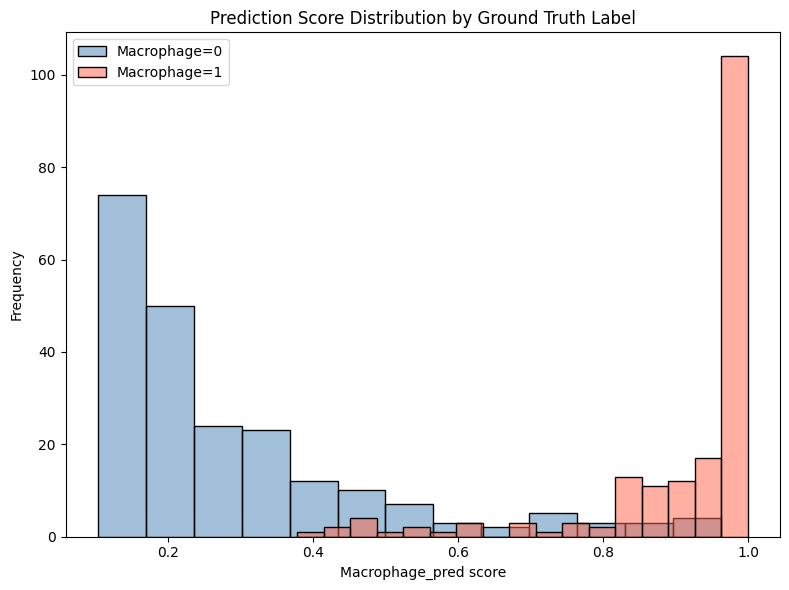

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df = adata.obs.dropna(subset=['Macrophage_pred', 'Macrophage']).copy()
plt.figure(figsize=(8, 6))
sns.histplot(df.loc[df['Macrophage'] == 0, 'Macrophage_pred'],
             color='steelblue', alpha=0.5, label='Macrophage=0')
sns.histplot(df.loc[df['Macrophage'] == 1, 'Macrophage_pred'],
             color='tomato',    alpha=0.5, label='Macrophage=1')
plt.legend()
plt.xlabel('Macrophage_pred score')
plt.ylabel('Frequency')
plt.title('Prediction Score Distribution by Ground Truth Label')
plt.tight_layout()
plt.show()

Best threshold (Youden's J): 0.539  J=0.860


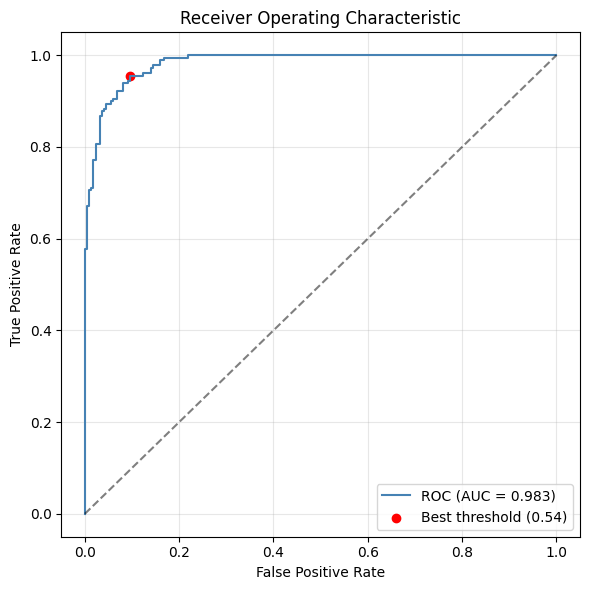

In [26]:
from sklearn.metrics import roc_curve, auc

df_roc = adata.obs.dropna(subset=['Macrophage_pred', 'Macrophage']).copy()
df_roc['Macrophage'] = df_roc['Macrophage'].astype(int)

fpr, tpr, thresholds = roc_curve(df_roc['Macrophage'], df_roc['Macrophage_pred'])
roc_auc = auc(fpr, tpr)

youdenJ     = tpr - fpr
best_thresh = thresholds[np.argmax(youdenJ)]
print(f"Best threshold (Youden\'s J): {best_thresh:.3f}  J={youdenJ.max():.3f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})', color='steelblue')
plt.scatter(fpr[np.argmax(youdenJ)], tpr[np.argmax(youdenJ)],
            marker='o', color='red', label=f'Best threshold ({best_thresh:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

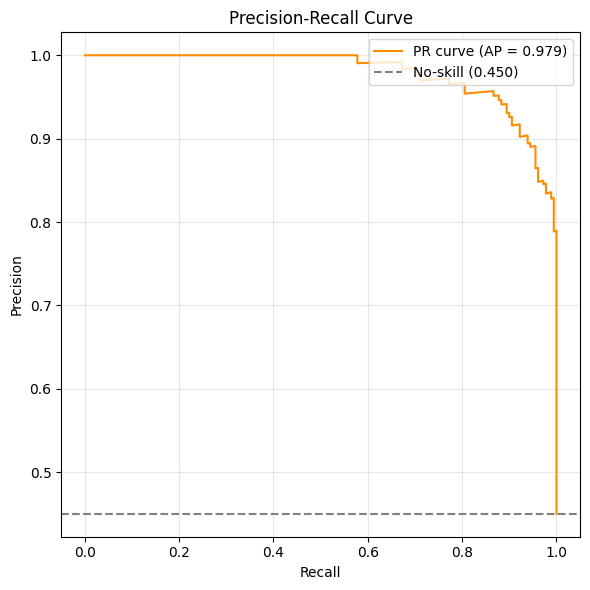

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

df_pr = adata.obs.dropna(subset=['Macrophage_pred', 'Macrophage']).copy()
df_pr['Macrophage'] = df_pr['Macrophage'].astype(int)
precision, recall, _ = precision_recall_curve(df_pr['Macrophage'], df_pr['Macrophage_pred'])
ap       = average_precision_score(df_pr['Macrophage'], df_pr['Macrophage_pred'])
baseline = df_pr['Macrophage'].mean()

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, color='darkorange', label=f'PR curve (AP = {ap:.3f})')
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'No-skill ({baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
threshold_val = np.percentile(adata.obs['Macrophage_pred'], 50)
print(f"Median prediction score (threshold): {threshold_val:.4f}")
adata.obs['Macrophage_pred_binary'] = (adata.obs['Macrophage_pred'] >= 0.4).astype(int)
adata.obs['Macrophage_pred_binary'].value_counts()

Median prediction score (threshold): 0.4995


Macrophage_pred_binary
1    221
0    179
Name: count, dtype: int64

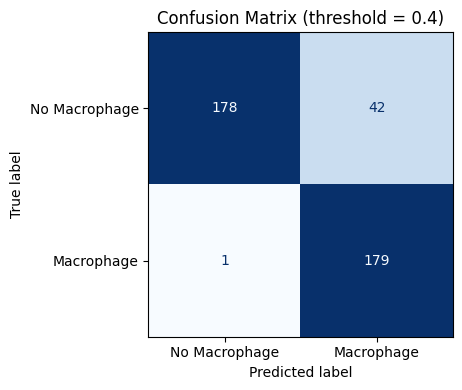

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df_cm = adata.obs.dropna(subset=['Macrophage_pred_binary', 'Macrophage']).copy()
cm   = confusion_matrix(df_cm['Macrophage'].astype(int),
                        df_cm['Macrophage_pred_binary'].astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Macrophage', 'Macrophage'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (threshold = 0.4)')
plt.tight_layout()
plt.show()

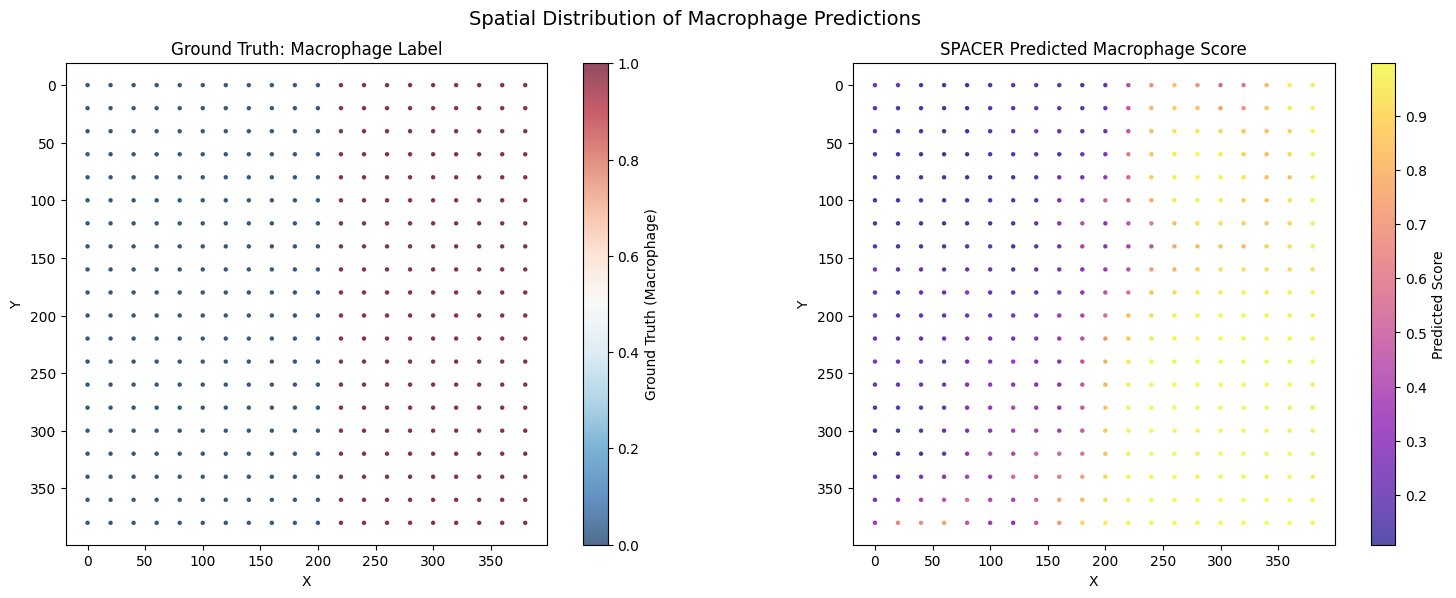

In [30]:
n_cells = len(adata.obs)
marker_size = max(2, min(20, 2000 / n_cells))  # scale dot size to dataset

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc0 = axes[0].scatter(
    adata.obs['X'], adata.obs['Y'],
    c=adata.obs['Macrophage'].astype(float),
    cmap='RdBu_r', s=marker_size, alpha=0.7
)
plt.colorbar(sc0, ax=axes[0], label='Ground Truth (Macrophage)')
axes[0].set_title('Ground Truth: Macrophage Label')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
axes[0].invert_yaxis(); axes[0].set_aspect('equal')

vmin = adata.obs['Macrophage_pred'].quantile(0.01)
vmax = adata.obs['Macrophage_pred'].quantile(0.99)
sc1 = axes[1].scatter(
    adata.obs['X'], adata.obs['Y'],
    c=adata.obs['Macrophage_pred'],
    cmap='plasma', s=marker_size, alpha=0.7, vmin=vmin, vmax=vmax
)
plt.colorbar(sc1, ax=axes[1], label='Predicted Score')
axes[1].set_title('SPACER Predicted Macrophage Score')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].invert_yaxis(); axes[1].set_aspect('equal')

plt.suptitle('Spatial Distribution of Macrophage Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('spatial_macrophage_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
matched = adata.obs[(adata.obs['Macrophage'] == 1) & (adata.obs['Macrophage_pred_binary'] == 1)]
print(f"True positives: {len(matched)} / {(adata.obs['Macrophage']==1).sum()} ground-truth positive cells")
matched[['X','Y','Macrophage','Macrophage_pred','Macrophage_pred_binary']].head(10)

True positives: 179 / 180 ground-truth positive cells


,X,Y,Macrophage,Macrophage_pred,Macrophage_pred_binary
CELL_00011-1,220.0,0.0,1,0.426641,1
CELL_00012-1,240.0,0.0,1,0.695324,1
CELL_00013-1,260.0,0.0,1,0.858642,1
CELL_00014-1,280.0,0.0,1,0.699150,1
CELL_00015-1,300.0,0.0,1,0.555146,1
CELL_00016-1,320.0,0.0,1,0.600728,1
CELL_00017-1,340.0,0.0,1,0.821454,1
CELL_00018-1,360.0,0.0,1,0.956521,1
CELL_00019-1,380.0,0.0,1,0.969552,1
CELL_00031-1,220.0,20.0,1,0.463269,1
